### Grupo 11

Álvaro Serrano Delmás  
Manuel Alejandro Torrealba Torrealba  
Alejandro Alemán Alemán

Tenemos que:
1. Poner en blanco y negro 
2. Quitar el ruido a la imagen
3. Detectar los bordes (en el primer frame solo) SIFT solo esquinas
4. Y lucas (desplazar la matriz segun el incremento entre framen 1 y 2, ...)

En este notebook hemos experimentado con el método Lucas–Kanade, probando de forma aislada los pasos que deben ejecutarse en cada frame para calcular el movimiento entre imágenes consecutivas. Para la detección de puntos de interés hemos utilizado SIFT, ya que este método no solo detecta bordes, sino también esquinas. Esto resulta especialmente útil para calcular movimientos, porque si únicamente se detectaran bordes horizontales o verticales, habría direcciones del movimiento que no podrían estimarse correctamente.


En esta celda hemos implementado los primeros tres pasos. Y hemos elegido un punto de interés para poder hacer pruebas con el algorítmo de Lucas. EL código es de chat gpt con ajustes propios.

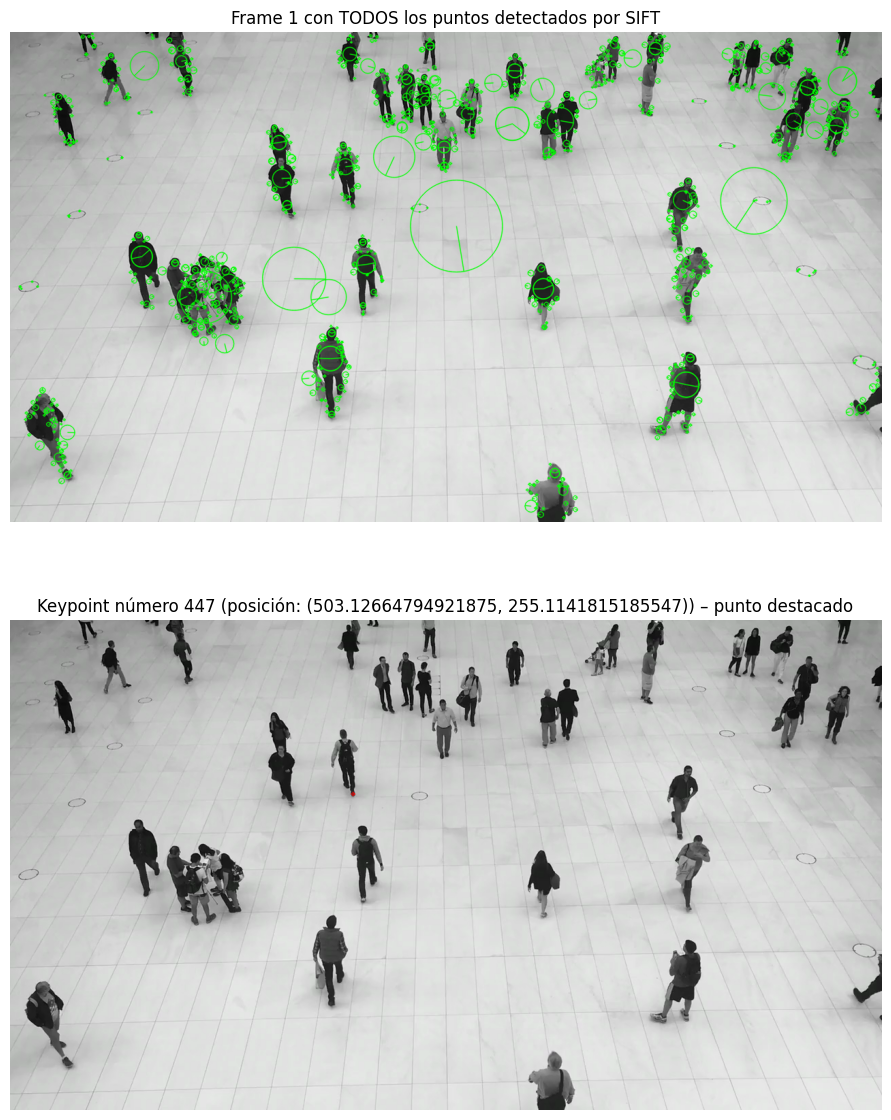

In [33]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

ruta_video = "videos/people2.mp4" 

cap = cv.VideoCapture(ruta_video)

# Leer el primer frame
ret1, frame1 = cap.read()
ret2, frame2 = cap.read()

cap.release()

gray1 = cv.cvtColor(frame1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)

gray1 = cv.GaussianBlur(gray1, (5,5), 1)
gray2 = cv.GaussianBlur(gray2, (5,5), 1)

sift = cv.SIFT_create()

keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)

kp_index = 447

kp20 = keypoints1[kp_index]   # obtener ese keypoint

frame1_sift = cv.drawKeypoints( frame1, 
            keypoints1,
            None, 
            color=(0,255,0), 
            flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS )

frame_kp20 = cv.drawKeypoints(
    frame1,
    [kp20],      
    None,
    color=(0,0,255),  
    flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(12, 14))


plt.subplot(2, 1, 1)
plt.imshow(cv.cvtColor(frame1_sift, cv.COLOR_BGR2RGB))
plt.title("Frame 1 con TODOS los puntos detectados por SIFT")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(cv.cvtColor(frame_kp20, cv.COLOR_BGR2RGB))
plt.title(f"Keypoint número {kp_index} (posición: {kp20.pt}) – punto destacado")
plt.axis('off')

plt.show()



Obtenemos las ventanas de ambos frames

In [34]:
x, y = int(kp20.pt[0]), int(kp20.pt[1])

win = 2   # radio → ventana 5x5

ventana_f1 = gray1[y-win:y+win+1, x-win:x+win+1]
ventana_f2 = gray2[y-win:y+win+1, x-win:x+win+1]


Cálculo de gradiente x e y

In [35]:
Ix = cv.Sobel(gray1, cv.CV_32F, 1, 0, ksize=3)
Iy = cv.Sobel(gray1, cv.CV_32F, 0, 1, ksize=3)
It = gray2.astype("float32") - gray1.astype("float32")

Ix_ventana = Ix[y-win:y+win+1, x-win:x+win+1].flatten()
Iy_ventana = Iy[y-win:y+win+1, x-win:x+win+1].flatten()
It_ventana = It[y-win:y+win+1, x-win:x+win+1].flatten()


In [36]:
print(Ix)
print(Iy)
print(It)

[[0. 0. 0. ... 4. 4. 0.]
 [0. 0. 0. ... 4. 4. 0.]
 [0. 0. 0. ... 4. 4. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ... -2. -2. -2.]
 [ 0.  0.  0. ... -4. -4. -4.]
 ...
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[-2. -2. -2. ... -3. -2. -2.]
 [-2. -2. -2. ... -4. -3. -2.]
 [-1. -1. -1. ... -4. -2. -2.]
 ...
 [ 1.  1.  1. ...  1.  1.  1.]
 [ 1.  1.  1. ...  1.  1.  1.]
 [ 1.  1.  1. ...  1.  1.  1.]]


In [37]:

S = np.column_stack((Ix_ventana, Iy_ventana))    
T = -It_ventana.reshape(-1, 1)                 

In [38]:
STS = S.T @ S            # (2x2)
STT = S.T @ T            # (2x1)

dp = np.linalg.inv(STS) @ STT
u, v = dp[0,0], dp[1,0]


In [39]:
print("Desplazamiento estimado del keypoint:")
print(f"u (x): {u:.3f} píxeles")
print(f"v (y): {v:.3f} píxeles")


Desplazamiento estimado del keypoint:
u (x): -0.187 píxeles
v (y): -0.718 píxeles


chatgpt para obtener gráfica

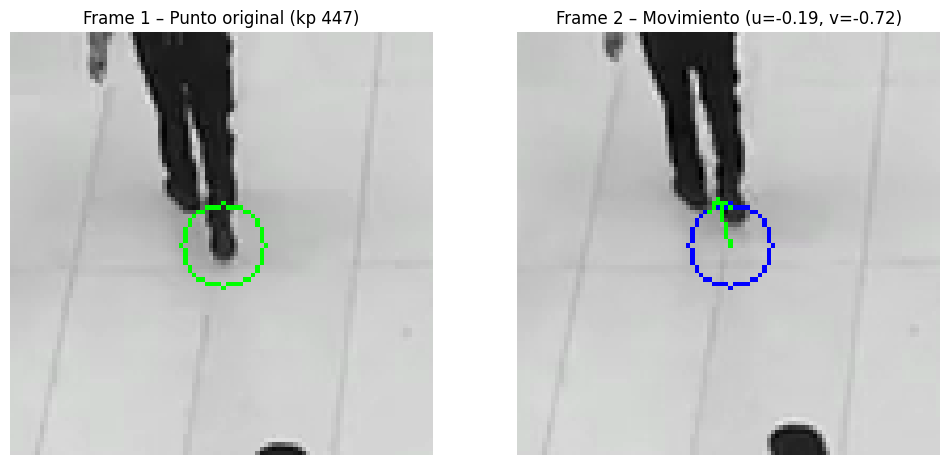

In [54]:
R = 50   

# Coordenadas absolutas del kp
x0, y0 = int(x), int(y)

# Recorte alrededor del keypoint
y_min = max(0, y0 - R)
y_max = min(gray1.shape[0], y0 + R)
x_min = max(0, x0 - R)
x_max = min(gray1.shape[1], x0 + R)

crop1 = frame1[y_min:y_max, x_min:x_max].copy()
crop2 = frame2[y_min:y_max, x_min:x_max].copy()

# ========= AMPLIFICAR EL VECTOR ================
SCALE = 15
dx = int(round(u * SCALE))
dy = int(round(v * SCALE))
# ===============================================

# Coordenadas RELATIVAS AL RECORTE
px0 = x0 - x_min
py0 = y0 - y_min

px1 = px0 + dx
py1 = py0 + dy

# Limitar dentro del recorte
px1 = np.clip(px1, 0, crop2.shape[1] - 1)
py1 = np.clip(py1, 0, crop2.shape[0] - 1)

# -------------------------------------------------------
# DIBUJAR EL PUNTO ORIGINAL EN FRAME 1 (CÍRCULO GRANDE)
# -------------------------------------------------------
cv.circle(crop1, (px0, py0), 10, (0, 255, 0), 1)   # Verde, grosor 3

# -------------------------------------------------------
# DIBUJAR EL PUNTO ORIGINAL Y LA FLECHA EN FRAME 2
# -------------------------------------------------------
# Punto original
cv.circle(crop2, (px0, py0), 10, (255, 0, 0), 1)   # Azul para diferenciar

# Flecha hacia su nuevo punto
cv.arrowedLine(
    crop2,
    (px0, py0),
    (px1, py1),
    (0, 255, 0),
    1,
    tipLength=0.3
)


# -------------------------------------------------------
# MOSTRAR AMBAS IMÁGENES
# -------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(crop1, cv.COLOR_BGR2RGB))
plt.title(f"Frame 1 – Punto original (kp {kp_index})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(crop2, cv.COLOR_BGR2RGB))
plt.title(f"Frame 2 – Movimiento (u={u:.2f}, v={v:.2f})")
plt.axis('off')

plt.show()

